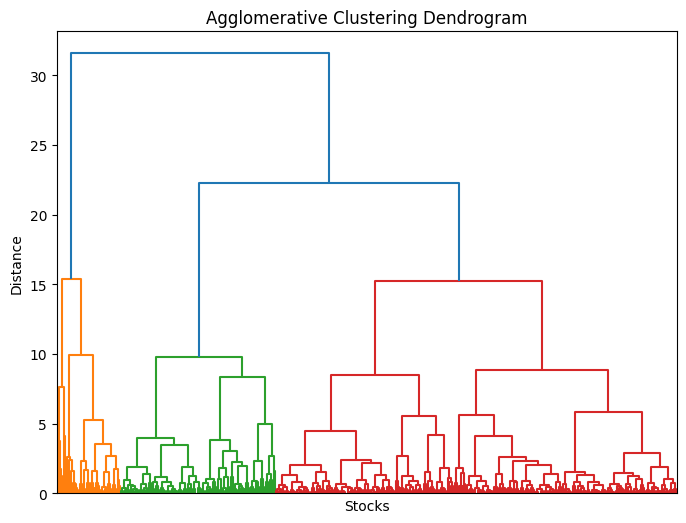


Agglomerative Clustering - Silhouette Scores


,N_Clusters,Silhouette_Score
0,2,0.520552
1,3,0.311480
2,4,0.316794
3,5,0.260334
4,6,0.262877
5,7,0.239445
6,8,0.222862


Selected number of clusters for Agglomerative Clustering: 2

Agglomerative Cluster Sizes


,Count
Agglomerative_Cluster,
0,445
1,51



Agglomerative Cluster Profiles


,Daily_Return,Beta,Annual_Volatility
Agglomerative_Cluster,,,
0,0.0003,0.8624,0.2904
1,0.0015,1.6529,0.5230


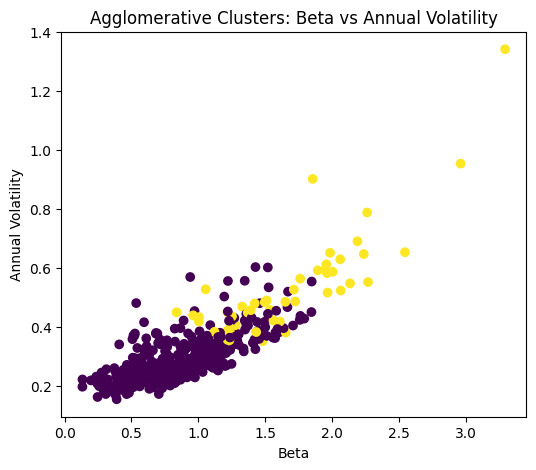

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("sp500_metrics.csv")

features = ["Daily_Return", "Beta", "Annual_Volatility"]
meta_cols = [col for col in ["Ticker", "Symbol", "Security", "GICS Sector", "Sector"] if col in df.columns]
data = df[meta_cols + features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])

# dendrogram
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(8, 6))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Stocks")
plt.ylabel("Distance")
plt.show()

# silhouette analysis for candidate cluster numbers
agg_results = []
for n in range(2, 9):
    model = AgglomerativeClustering(n_clusters=n, linkage="ward")
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    agg_results.append([n, score])

agg_scores = pd.DataFrame(agg_results, columns=["N_Clusters", "Silhouette_Score"])
print("\nAgglomerative Clustering - Silhouette Scores")
display(agg_scores)

# choose best value of N from the scores
best_n = int(agg_scores.sort_values("Silhouette_Score", ascending=False).iloc[0]["N_Clusters"])
agg_model = AgglomerativeClustering(n_clusters=best_n, linkage="ward")
data["Agglomerative_Cluster"] = agg_model.fit_predict(X_scaled)

# cluster summary
agg_profile = data.groupby("Agglomerative_Cluster")[features].mean().round(4)
agg_size = data["Agglomerative_Cluster"].value_counts().sort_index().rename("Count")
print(f"Selected number of clusters for Agglomerative Clustering: {best_n}\n")
print("Agglomerative Cluster Sizes")
display(agg_size.to_frame())
print("\nAgglomerative Cluster Profiles")
display(agg_profile)

# visualisation
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    data["Beta"],
    data["Annual_Volatility"],
    c=data["Agglomerative_Cluster"])
plt.xlabel("Beta")
plt.ylabel("Annual Volatility")
plt.title("Agglomerative Clusters: Beta vs Annual Volatility")
plt.show()
data.to_csv("sp500_taskB_agglomerative.csv", index=False)

,K,Silhouette_Score
0,2,0.462195
1,3,0.310968
2,4,0.321350
3,5,0.298465
4,6,0.295294
5,7,0.293985
6,8,0.290360


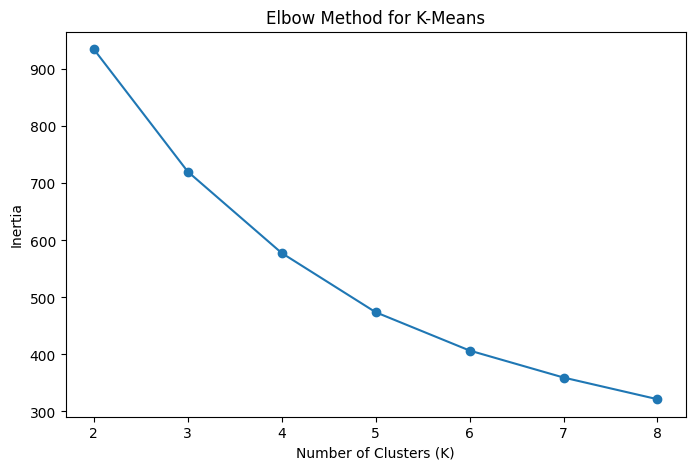


Selected number of clusters: 2


,Count
KMeans_Cluster,
0,104
1,392


,Daily_Return,Beta,Annual_Volatility
KMeans_Cluster,,,
0,0.0008,1.5398,0.4737
1,0.0003,0.7855,0.2720


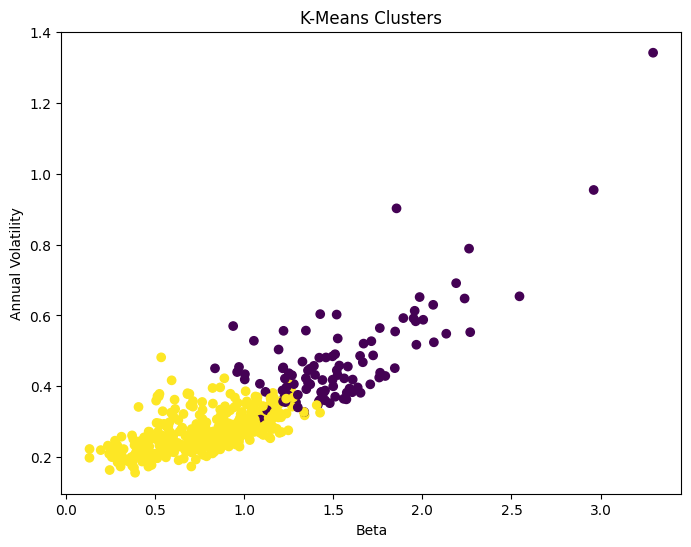

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

k_results = []
inertia_values = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertia_values.append(model.inertia_)
    sil = silhouette_score(X_scaled, labels)
    k_results.append([k, sil])

k_scores = pd.DataFrame(k_results, columns=["K", "Silhouette_Score"])
display(k_scores)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

best_k = int(k_scores.sort_values("Silhouette_Score", ascending=False).iloc[0]["K"])

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
data["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

kmeans_size = data["KMeans_Cluster"].value_counts().sort_index().rename("Count")
kmeans_profile = data.groupby("KMeans_Cluster")[["Daily_Return", "Beta", "Annual_Volatility"]].mean().round(4)

print("\nSelected number of clusters:", best_k)
display(kmeans_size.to_frame())
display(kmeans_profile)

plt.figure(figsize=(8, 6))
plt.scatter(data["Beta"], data["Annual_Volatility"], c=data["KMeans_Cluster"])
plt.xlabel("Beta")
plt.ylabel("Annual Volatility")
plt.title("K-Means Clusters")
plt.show()